In [2]:
from ultralytics import YOLO
import cv2
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

In [3]:
model = YOLO('runs/train/product_model/weights/best.pt')
img = "images/val/IMG_4664.jpeg"  
results = model.predict(source=img, conf=0.5)

# extract bounding boxes and class indices
bboxes = results[0].boxes.xyxy.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy()

# identify the product bounding box (ignore the quarter)
product_bbox = None
for bbox, cls in zip(bboxes, classes):
    label = model.names[int(cls)].lower()
    if label == "product":
        product_bbox = bbox
        break

if product_bbox is None:
    raise ValueError("Product bounding box not detected.")


image 1/1 /Users/andreanoh/Documents/Spring 2025 6010 ComputerVision/cv_product_info_extract/images/val/IMG_4664.jpeg: 640x480 1 quarter, 1 product, 108.0ms
Speed: 13.4ms preprocess, 108.0ms inference, 6.6ms postprocess per image at shape (1, 3, 640, 480)


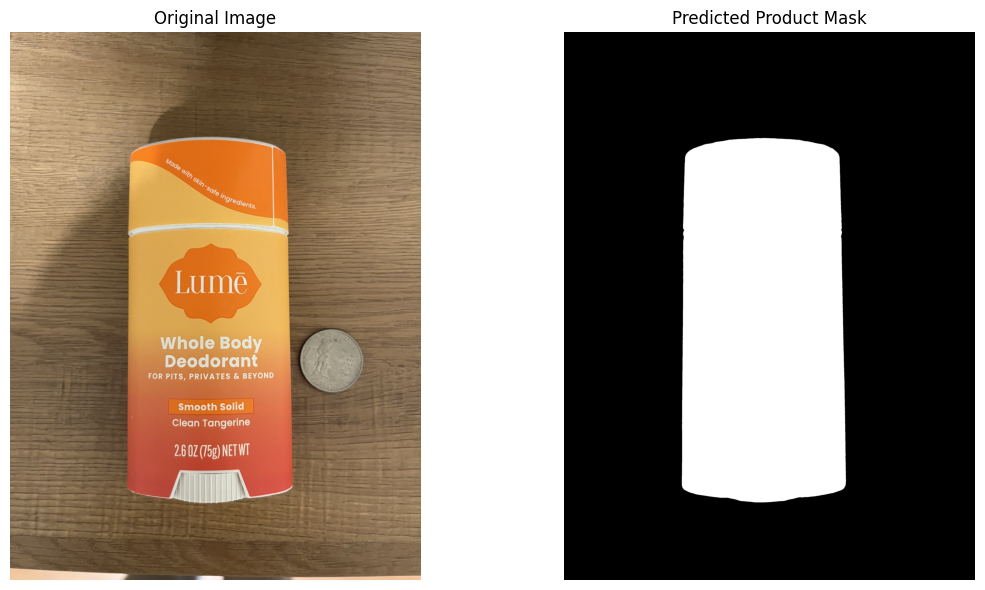

In [4]:
image_bgr = cv2.imread(img, cv2.IMREAD_COLOR) # original image

# load SAM
HOME = os.getcwd()
CHECKPOINT_PATH = os.path.join(HOME, "sam_vit_h_4b8939.pth")
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(DEVICE)
mask_predictor = SamPredictor(sam)

boxes_np = np.array([product_bbox])
boxes_tensor = torch.from_numpy(boxes_np).to(torch.float)
transformed_boxes = mask_predictor.transform.apply_boxes_torch(boxes_tensor, image_bgr.shape[:2])
mask_predictor.set_image(image_bgr) # image in the SAM predictor

# SAM on the product only
masks, scores, logits = mask_predictor.predict_torch(
    boxes=transformed_boxes,
    multimask_output=False,  # set to False to obtain a single mask prediction
    point_coords=None,
    point_labels=None
)

final_mask = masks[0][0].cpu().numpy().astype(np.uint8) # predicted mask
final_mask = final_mask * 255 # for visualization

# # save the mask
# mask_dir = os.path.join("runs", "segment")
# os.makedirs(mask_dir, exist_ok=True)
# mask_filename = os.path.join(mask_dir, f"mask_{os.path.basename(img)}")
# cv2.imwrite(mask_filename, final_mask)

# visualization: white for mask, black for background
final_mask_color = np.zeros_like(image_bgr)
final_mask_color[final_mask != 0] = [255, 255, 255]

# original image and predicted product mask
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(final_mask_color, cv2.COLOR_BGR2RGB))
axes[1].set_title("Predicted Product Mask")
axes[1].axis('off')
plt.tight_layout()
plt.show()


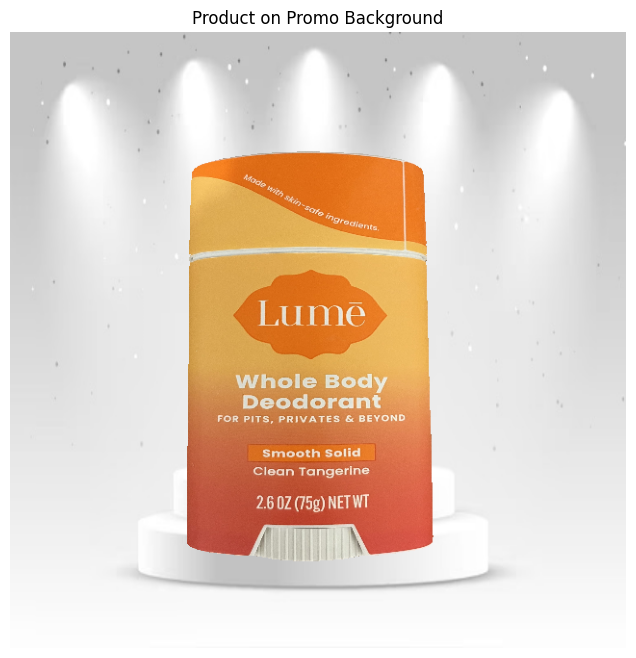

True

In [5]:
promo_img_path = "images/promo2.jpeg" # read promo background
promo_bgr = cv2.imread(promo_img_path, cv2.IMREAD_COLOR) 
promo_resized = cv2.resize(promo_bgr, (640, 640)) # resize promo background

product_image = cv2.resize(image_bgr, (640, 640)) # product image, resize if needed
final_mask_resized = cv2.resize(final_mask, (640, 640), interpolation=cv2.INTER_NEAREST) # resize the product mask (use nearest neighbor interpolation for masks)
product_only = cv2.bitwise_and(product_image, product_image, mask=final_mask_resized) # use the mask to extract the product from the original image
final_composite = promo_resized.copy() # promo background to place the product
final_composite[final_mask_resized != 0] = product_only[final_mask_resized != 0] # where the product mask is non-zero, replace the promo with product pixels

# display
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(final_composite, cv2.COLOR_BGR2RGB))
plt.title("Product on Promo Background")
plt.axis("off")
plt.show()
cv2.imwrite("composite_product_on_promo.jpeg", final_composite)

Increase the size of the product.

Product bounding box: x=184, y=124, w=256, h=426


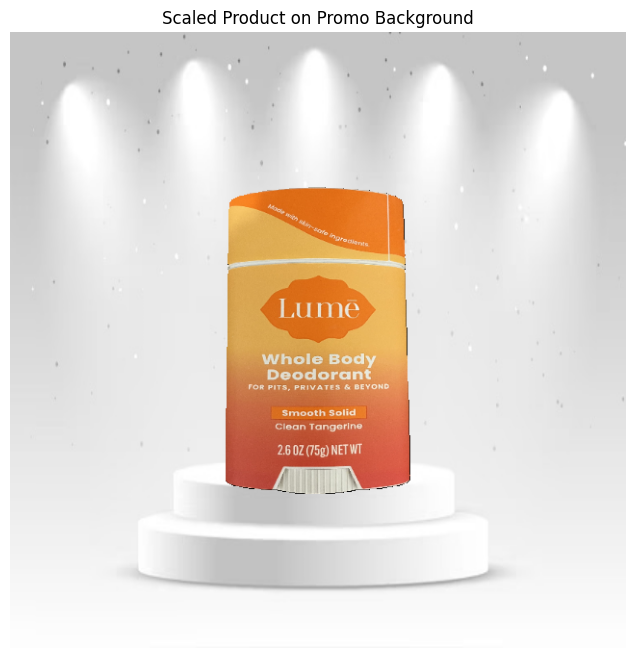

In [8]:
# Step 1: Extract the product's tight bounding box from the mask
x, y, w, h = cv2.boundingRect(final_mask_resized)
print(f"Product bounding box: x={x}, y={y}, w={w}, h={h}")

# Crop the product region and its mask
cropped_product = product_only[y:y+h, x:x+w]
cropped_mask = final_mask_resized[y:y+h, x:x+w]

# Step 2: Increase the size of the product by a scaling factor
scale_factor = 0.75  # Increase size by 50%; adjust as needed
new_width = int(w * scale_factor)
new_height = int(h * scale_factor)
resized_product = cv2.resize(cropped_product, (new_width, new_height), interpolation=cv2.INTER_LINEAR)
# Use nearest neighbor interpolation for the mask to keep it binary
resized_mask = cv2.resize(cropped_mask, (new_width, new_height), interpolation=cv2.INTER_NEAREST)

# Step 3: Prepare the promo background by resizing it to 640x640
promo_img_path = "images/promo2.jpeg"
promo_bgr = cv2.imread(promo_img_path, cv2.IMREAD_COLOR)
promo_resized = cv2.resize(promo_bgr, (640, 640))

# Step 4: Composite the product onto the promo background using alpha blending
# Convert the resized mask into an alpha channel (normalized to [0, 1])
alpha = resized_mask.astype(np.float32) / 255.0
# Merge into a 3-channel mask so it can be applied on a BGR image
alpha = cv2.merge([alpha, alpha, alpha])

# Center the product on the promo background
final_composite = promo_resized.copy()
center_x = final_composite.shape[1] // 2
center_y = final_composite.shape[0] // 2
top_left_x = center_x - new_width // 2
top_left_y = center_y - new_height // 2

# Define region of interest (ROI) on the promo background
roi = final_composite[top_left_y: top_left_y+new_height, top_left_x: top_left_x+new_width].astype(np.float32)

# Blend the product with the background using the alpha mask
blended = roi * (1 - alpha) + resized_product.astype(np.float32) * alpha
final_composite[top_left_y: top_left_y+new_height, top_left_x: top_left_x+new_width] = blended.astype(np.uint8)

# Step 5: Display and save the final composite image
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(final_composite, cv2.COLOR_BGR2RGB))
plt.title("Scaled Product on Promo Background")
plt.axis("off")
plt.show()

Address the rough edges - I dont want to smooth the whole product because that blurs the brand name. I only want to smooth the outer border of pixels. 

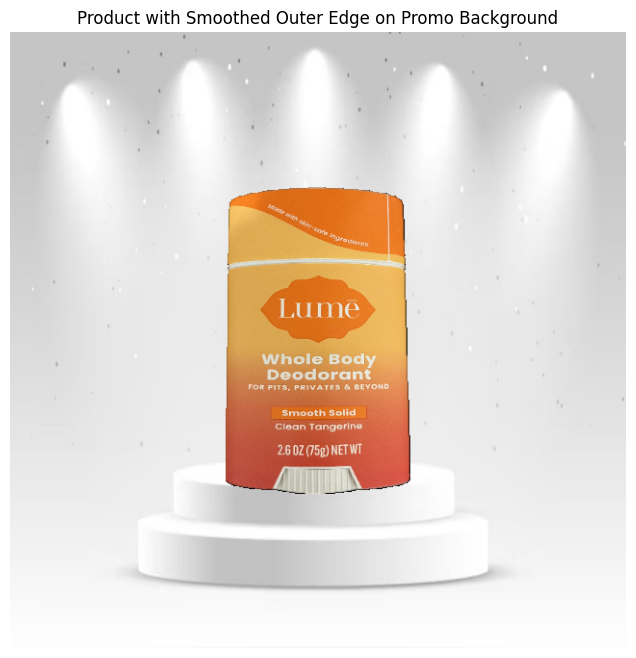

In [10]:
# Step 1: Extract a tight bounding box around the product using the mask
x, y, w, h = cv2.boundingRect(final_mask_resized)
cropped_product = product_only[y:y+h, x:x+w]
cropped_mask = final_mask_resized[y:y+h, x:x+w]

# Step 2: Create a border mask that captures only the outer edge of the product
# Erode the mask to remove the border pixels from the interior
kernel = np.ones((5, 5), np.uint8)  # Adjust kernel size for border thickness
eroded_mask = cv2.erode(cropped_mask, kernel, iterations=1)
# The border is the difference between the original mask and its eroded version
border_mask = cv2.subtract(cropped_mask, eroded_mask)

# Step 3: Create a blurred version of the cropped product image
# This blurred image will only be used for the outer edge
cropped_product_blurred = cv2.GaussianBlur(cropped_product, (7, 7), 0)

# Step 4: Replace only the border pixels in the original cropped product with the blurred pixels
final_cropped_product = cropped_product.copy()
# For pixels where the border mask is non-zero, substitute the blurred version
final_cropped_product[border_mask > 0] = cropped_product_blurred[border_mask > 0]

# Step 5: Increase the size of the product by a scaling factor
scale_factor = 0.75  # Increase size by 50%; adjust as needed
new_width = int(w * scale_factor)
new_height = int(h * scale_factor)
resized_product = cv2.resize(final_cropped_product, (new_width, new_height), interpolation=cv2.INTER_LINEAR)
# Resize the mask using nearest neighbor to preserve binary values
resized_mask = cv2.resize(cropped_mask, (new_width, new_height), interpolation=cv2.INTER_NEAREST)

# Step 6: Composite the resized product onto the promo background
promo_img_path = "images/promo2.jpeg"
promo_bgr = cv2.imread(promo_img_path, cv2.IMREAD_COLOR)
promo_resized = cv2.resize(promo_bgr, (640, 640))

# Convert the resized mask into an alpha channel (range [0,1])
alpha = resized_mask.astype(np.float32) / 255.0
# Merge to make a 3-channel alpha mask
alpha = cv2.merge([alpha, alpha, alpha])

# Center the product on the promo background
final_composite = promo_resized.copy()
center_x = final_composite.shape[1] // 2
center_y = final_composite.shape[0] // 2
top_left_x = center_x - new_width // 2
top_left_y = center_y - new_height // 2

# Define the region of interest (ROI) on the background
roi = final_composite[top_left_y: top_left_y+new_height, top_left_x: top_left_x+new_width].astype(np.float32)

# Blend the product into the ROI using the alpha mask
blended = roi * (1 - alpha) + resized_product.astype(np.float32) * alpha
final_composite[top_left_y: top_left_y+new_height, top_left_x: top_left_x+new_width] = blended.astype(np.uint8)

# Step 7: Display and save the final composite image
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(final_composite, cv2.COLOR_BGR2RGB))
plt.title("Product with Smoothed Outer Edge on Promo Background")
plt.axis("off")
plt.show()


try new background image

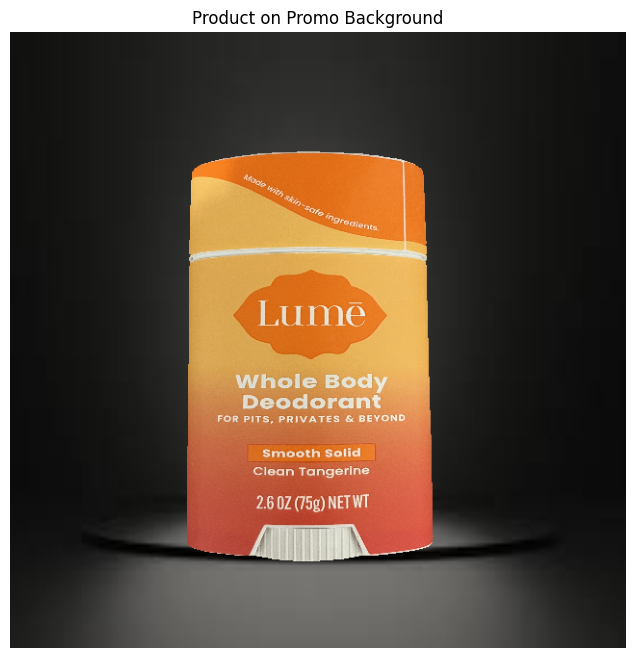

In [11]:
promo_img_path = "images/promo_dark.jpeg" # read promo background
promo_bgr = cv2.imread(promo_img_path, cv2.IMREAD_COLOR) 
promo_resized = cv2.resize(promo_bgr, (640, 640)) # resize promo background

product_image = cv2.resize(image_bgr, (640, 640)) # product image, resize if needed
final_mask_resized = cv2.resize(final_mask, (640, 640), interpolation=cv2.INTER_NEAREST) # resize the product mask (use nearest neighbor interpolation for masks)
product_only = cv2.bitwise_and(product_image, product_image, mask=final_mask_resized) # use the mask to extract the product from the original image
final_composite = promo_resized.copy() # promo background to place the product
final_composite[final_mask_resized != 0] = product_only[final_mask_resized != 0] # where the product mask is non-zero, replace the promo with product pixels

# display
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(final_composite, cv2.COLOR_BGR2RGB))
plt.title("Product on Promo Background")
plt.axis("off")
plt.show()

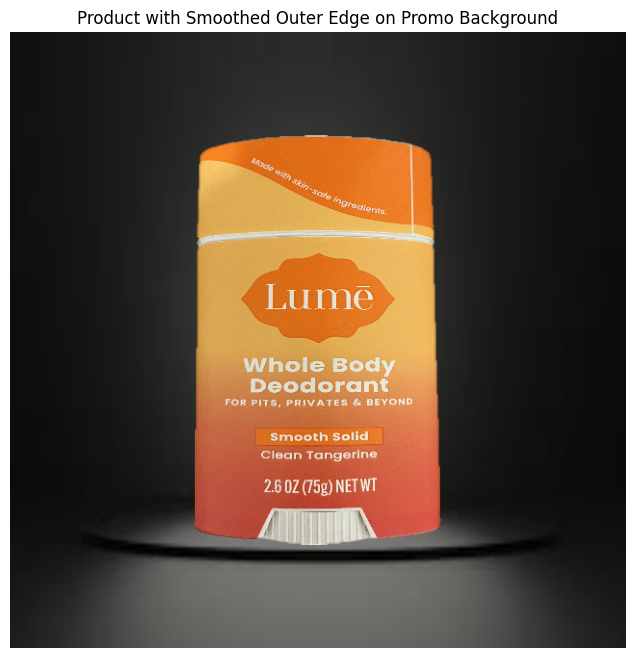

True

In [12]:
# Step 1: Extract a tight bounding box around the product using the mask
x, y, w, h = cv2.boundingRect(final_mask_resized)
cropped_product = product_only[y:y+h, x:x+w]
cropped_mask = final_mask_resized[y:y+h, x:x+w]

# Step 2: Create a border mask that captures only the outer edge of the product
# Erode the mask to remove the border pixels from the interior
kernel = np.ones((5, 5), np.uint8)  # Adjust kernel size for border thickness
eroded_mask = cv2.erode(cropped_mask, kernel, iterations=1)
# The border is the difference between the original mask and its eroded version
border_mask = cv2.subtract(cropped_mask, eroded_mask)

# Step 3: Create a blurred version of the cropped product image
# This blurred image will only be used for the outer edge
cropped_product_blurred = cv2.GaussianBlur(cropped_product, (7, 7), 0)

# Step 4: Replace only the border pixels in the original cropped product with the blurred pixels
final_cropped_product = cropped_product.copy()
# For pixels where the border mask is non-zero, substitute the blurred version
final_cropped_product[border_mask > 0] = cropped_product_blurred[border_mask > 0]

# Step 5: Increase the size of the product by a scaling factor
scale_factor = 1  # no increase
new_width = int(w * scale_factor)
new_height = int(h * scale_factor)
resized_product = cv2.resize(final_cropped_product, (new_width, new_height), interpolation=cv2.INTER_LINEAR)
# Resize the mask using nearest neighbor to preserve binary values
resized_mask = cv2.resize(cropped_mask, (new_width, new_height), interpolation=cv2.INTER_NEAREST)

# Step 6: Composite the resized product onto the promo background
promo_img_path = "images/promo_dark.jpeg"
promo_bgr = cv2.imread(promo_img_path, cv2.IMREAD_COLOR)
promo_resized = cv2.resize(promo_bgr, (640, 640))

# Convert the resized mask into an alpha channel (range [0,1])
alpha = resized_mask.astype(np.float32) / 255.0
# Merge to make a 3-channel alpha mask
alpha = cv2.merge([alpha, alpha, alpha])

# Center the product on the promo background
final_composite = promo_resized.copy()
center_x = final_composite.shape[1] // 2
center_y = final_composite.shape[0] // 2
top_left_x = center_x - new_width // 2
top_left_y = center_y - new_height // 2

# Define the region of interest (ROI) on the background
roi = final_composite[top_left_y: top_left_y+new_height, top_left_x: top_left_x+new_width].astype(np.float32)

# Blend the product into the ROI using the alpha mask
blended = roi * (1 - alpha) + resized_product.astype(np.float32) * alpha
final_composite[top_left_y: top_left_y+new_height, top_left_x: top_left_x+new_width] = blended.astype(np.uint8)

# Step 7: Display and save the final composite image
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(final_composite, cv2.COLOR_BGR2RGB))
plt.title("Product with Smoothed Outer Edge on Promo Background")
plt.axis("off")
plt.show()

cv2.imwrite("composite_product_smoothed_border_on_promo.jpeg", final_composite)